In [1]:
%load_ext autoreload
%autoreload 2

# **Feature Extraction**

El punto de partida del proyecto es un modelo que tome simplemente características numéricas de cada época (lapso de 30 segundos) e intente realizar una predicción a partir de estos. Para ello se realizó un proceso de *feature extraction* en el que, para cada época, se recortan las muestras de IHR y de acelerometría que caen en esa ventana de 30 s y se calculan las features descritas abajo.

Un punto importante sobre la **acelerometría**: features por cada eje (`x`, `y`, `z`) por separado dependen de la **orientación** del reloj (una persona acostada de lado vs. boca arriba da valores distintos aunque esté igual de quieta). Por eso todas las features de movimiento se calculan sobre la **magnitud del vector** $\|a\| = \sqrt{x^2+y^2+z^2}$, que es invariante a la orientación.

## Features *intra-época*

**IHR (Instantaneous Heart Rate):** Generamos features que son utilizadas en la práctica en el análisis de variabilidad de la frecuencia cardíaca (HRV, Heart Rate Variability) en el dominio del tiempo. Conceptos base:

- Intervalo *RR*: el tiempo (ms) entre dos latidos consecutivos, reconstruido como $\text{RR}=\tfrac{60.000\text{ms}}{\text{bpm}}$
- Intervalo *NN*: "nortmal-to-normal" interval, mismos intervalos que RR pero filtrando latidos irregulares (arritmias o errores del sensor). 

| Feature | Definición | Qué captura |
|---|---|---|
| `hr_mean` | Media del IHR. | Frecuencia cardíaca típica de la época. |
| `hr_std` | Desvío estándar (≈ SDNN=Standard Deviation of NN). | Variabilidad cardíaca global. |
| `hr_median` | Mediana. | Nivel central robusto ante outliers del IHR. |
| `hr_iqr` | Rango intercuartil (P75 − P25). | Dispersión robusta, alternativa a `std`. |
| `hr_rmssd` | "Root Means Square of Successive Differences". Raíz del promedio de las diferencias sucesivas al cuadrado, sobre intervalos RR (RR = 60000/bpm).| HRV de corto plazo / tono parasimpático. |
| `hr_pnn50` | "Percent of NN intervals differing by more than 50ms". Fracción de diferencias NN sucesivas mayores a 50 ms.| Otro índice de HRV vagal; complementa a `rmssd`. |
| `hr_slope` | Pendiente de la regresión lineal del IHR vs. tiempo dentro de la época. | Tendencia: aceleración o desaceleración cardíaca. |
| `hr_ptp` | Rango pico a pico. | Amplitud total de fluctuación; sensible a saltos de IHR. |
| `n_beats` | Cantidad de latidos válidos en la época. | Densidad de muestreo del IHR (no es uniforme); puede correlacionar con la calidad/estado. |

**Acelerometría (sobre la magnitud $\|a\|=\sqrt{x^2+y^2+z^2}$):**

*ENMO* (Euclidean Norm Minus One): se le resta $1g$ ($\approx 9.8m/s^2$) a la magnitud de la aceleración $\|a\|$ para quitar la gravedad y truncar a $>=0$. El estándar de oro en **actigrafía** para cuantificar movimiento neto.

$$
\text{ENMO} = \max (\|a\|- 1,\ 0)
$$

| Feature | Definición | Qué captura |
|---|---|---|
| `enmo_mean` | Media de ENMO. | Media de la aceleración dinámica neta. |
| `enmo_std` | Desvío estándar de ENMO. | Variabilidad del movimiento dentro de la época. |
| `acc_std` | Desvío estándar de $\|a\|$. | Cuánto fluctúa la magnitud; proxy de agitación. |
| `acc_ptp` | Rango pico a pico de $\|a\|$. | Amplitud máxima de movimiento. |
| `immobility_frac` | Fracción de muestras con $\|\,\|a\|-1\,\| < 0.05$ g. | Grado de inmovilidad; alto en sueño profundo, bajo en vigilia. |
| `jerk_std` | Desvío de la derivada de $\|a\|$. ($\text{jerk}=\tfrac{da}{dt}$: tasa de cambio de la aceleración) | Brusquedad del movimiento (sacudidas vs. deriva lenta). |

**Contexto del paciente:**

| Feature | Definición | Qué captura |
|---|---|---|
| `epoch_frac` | Índice de época normalizado (época / total de la noche). | Momento de la noche: la arquitectura del sueño depende fuertemente de él. |

## Features *inter-épocas*

Un modelo por época ignora que el sueño es altamente autocorrelacionado (las transiciones siguen reglas: no se salta de N3 a vigilia, REM sigue a NREM, etc.). Para inyectarle ese contexto temporal de forma explícita (lo que el LSTM hace implícitamente), sobre cada feature base se agregan, **dentro de cada noche** (respetando los límites entre noches):

- **`_lag1`, `_lag2`, `_lead1`, `_lead2`**: el valor de la feature 1 y 2 épocas antes y después (±30 y ±60 s de contexto).
- **`_delta1`**: diferencia con la época previa (`x[t] − x[t−1]`); un salto grande marca una transición de estado.
- **`_rmean`, `_rstd`**: media y desvío en una ventana móvil centrada de 5 épocas (±2), que suavizan el ruido y describen la dinámica local.

Además, una feature global de movimiento:

- **`epochs_since_move`**: cantidad de épocas transcurridas desde el último movimiento grande (ENMO medio > 0.05 g); proxy de qué tan asentado está el sueño.

Los valores en los bordes (lags/leads sin vecino) quedan como `NaN`, que **XGBoost maneja de forma nativa** aprendiendo una dirección por defecto. El dataset resultante (`data/epoch_features.csv`) tiene una fila por época, identificada por `subject`, `night` y `epoch`, con la etiqueta del experto (`expert_label`) como `label`. El recorte de cada noche a su ventana válida se aplica en memoria vía `EDA.load_night_clean`, sin modificar los CSV originales.


In [2]:
import sys
sys.path.append("..")

from src.feature_extraction import feature_extraction

c:\Users\agust\anaconda3\envs\pf_ml\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import os

# generar epoch_features.csv si no existe
FEATURES_PATH = "../data_extraction/epoch_features.csv"
if os.path.exists(FEATURES_PATH):
    print(f"{FEATURES_PATH} ya existe; se omite la extracción.")
else:
    feature_extraction()

P68-N4: 100%|██████████| 252/252 [18:11<00:00,  4.33s/night]


# **Split y entrenamiento del XGBoost**

Sobre el dataset de features entrenamos un **XGBoost** como modelo baseline (una predicción por época, sin secuencia).

**Partición de los datos.** Dividimos en **dev (80%)** y **test (20%)**, y dentro de dev en **train (80%)** y **validación (20%)**. La partición se hace **por paciente** (`GroupShuffleSplit` agrupando por `subject`), no por época: como las épocas de una misma noche/paciente están fuertemente correlacionadas, mezclarlas entre train y test produciría *fuga de información* y métricas optimistas. Agrupando por sujeto garantizamos que ningún paciente aparezca en más de un conjunto.

**Etiquetas.** El target es la etiqueta del experto (`label`). Descartamos las épocas marcadas como *Unknown* (clase 5). La validación se usa para *early stopping*.

**Evaluación.** Reportamos **F1-Score (macro)** y **Cohen's Kappa** sobre el test, comparando las predicciones contra dos referencias:
- **Expert**: la etiqueta del experto, que es el target con el que se entrenó.
- **Dreem**: el etiquetado automático de Dreem (basado en EEG). No es el target; mide cuánto coincide el modelo con una segunda anotación independiente.


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit

df = pd.read_csv("../data_extraction/epoch_features.csv")

# descartamos las épocas Unknown (clase 5) del target
df = df[df['label'] != 5].reset_index(drop=True)

meta_cols = ['subject', 'night', 'epoch', 'label', 'dreem']
feature_cols = [c for c in df.columns if c not in meta_cols]

X = df[feature_cols]
y = df['label'].values
groups = df['subject'].values

# dev (80%) / test (20%), agrupando por paciente
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
dev_idx, test_idx = next(gss.split(X, y, groups))

X_dev, y_dev, g_dev = X.iloc[dev_idx], y[dev_idx], groups[dev_idx]
X_test, y_test = X.iloc[test_idx], y[test_idx]
dreem_test = df['dreem'].values[test_idx]

# dentro de dev: train (80%) / validación (20%), también por paciente
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
tr_idx, val_idx = next(gss_val.split(X_dev, y_dev, g_dev))

X_train, y_train = X_dev.iloc[tr_idx], y_dev[tr_idx]
X_val, y_val = X_dev.iloc[val_idx], y_dev[val_idx]

print(f"épocas  -> train: {len(X_train)}  val: {len(X_val)}  test: {len(X_test)}")
print(f"pacientes -> train: {len(np.unique(g_dev[tr_idx]))}  "
      f"val: {len(np.unique(g_dev[val_idx]))}  test: {len(np.unique(groups[test_idx]))}")

épocas  -> train: 121829  val: 35897  test: 46212
pacientes -> train: 29  val: 8  test: 10


## Entrenamiento

In [5]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    early_stopping_rounds=30,
    n_jobs=-1,
    random_state=42,
)

model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
print(f"mejor iteración (early stopping): {model.best_iteration}")


mejor iteración (early stopping): 141


## Desempeño

Evaluamos sobre el conjunto de **test** con `classification_report`, que produce dos bloques distintos.

**Métricas por clase** (una fila por etapa, calculadas *one-vs-rest*: "esta clase vs. todo lo demás"):

- **Precision** $= \tfrac{TP}{TP + FP}$: de las épocas que el modelo *predijo* como esa clase, qué fracción era correcta. Penaliza los **falsos positivos**.
- **Recall** (sensibilidad) $= \tfrac{TP}{TP + FN}$: de las épocas que *realmente eran* de esa clase, qué fracción detectó el modelo. Penaliza los **falsos negativos**.
- **F1-score** $= 2\cdot\tfrac{P\cdot R}{P + R}$: media armónica de precision y recall. Las resume en un número; es alto solo si **ambas** lo son.
- **Support**: cantidad de épocas reales de esa clase en el test. No es una métrica, sino el tamaño de la clase: evidencia el **desbalance** (N2 $\gg$ N1).

**Resúmenes globales** (las tres filas finales, que NO son clases sino formas de agregar):

- **Accuracy** $= \tfrac{\text{aciertos}}{\text{total}}$: un único número global. Engaña bajo desbalance: está dominada por la clase mayoritaria (N2).
- **Macro avg**: promedio **simple** de las métricas por clase (cada clase pesa igual, sin importar su support). Es la métrica honesta bajo desbalance: la pésima detección de N1 la castiga fuerte.
- **Weighted avg**: promedio **ponderado por support** (las clases grandes pesan más); queda más cerca de la accuracy.

Además reportamos **Cohen's Kappa**, $\kappa = \tfrac{p_o - p_e}{1 - p_e}$, donde $p_o$ es el acuerdo observado y $p_e$ el esperado por azar. $\kappa = 0$ es azar puro y $\kappa = 1$ acuerdo perfecto. Es la métrica estándar en *sleep staging* porque descuenta el acierto trivial sobre la clase mayoritaria.

Comparamos contra dos referencias:
- **Expert**: el target de entrenamiento (etiqueta del experto humano).
- **Dreem**: anotación automática basada en EEG, independiente; mide el acuerdo con una segunda fuente (enmascarando sus épocas *Unknown*).

In [6]:
from sklearn.metrics import f1_score, cohen_kappa_score, classification_report

y_pred = model.predict(X_test)

# vs Expert (target de entrenamiento)
f1_exp = f1_score(y_test, y_pred, average='macro')
kappa_exp = cohen_kappa_score(y_test, y_pred)

# vs Dreem (segunda anotación); descartamos épocas Dreem Unknown
mask = dreem_test != 5
f1_dreem = f1_score(dreem_test[mask], y_pred[mask], average='macro')
kappa_dreem = cohen_kappa_score(dreem_test[mask], y_pred[mask])

print(f"Expert  ->  F1-macro: {f1_exp:.3f}   Cohen's Kappa: {kappa_exp:.3f}")
print(f"Dreem   ->  F1-macro: {f1_dreem:.3f}   Cohen's Kappa: {kappa_dreem:.3f}")
print()
print("Reporte por clase (vs Expert):")
print(classification_report(y_test, y_pred, target_names=['Wake', 'N1', 'N2', 'N3', 'REM']))


Expert  ->  F1-macro: 0.469   Cohen's Kappa: 0.375
Dreem   ->  F1-macro: 0.464   Cohen's Kappa: 0.374

Reporte por clase (vs Expert):
              precision    recall  f1-score   support

        Wake       0.72      0.65      0.69      5496
          N1       0.29      0.01      0.01      3251
          N2       0.55      0.54      0.54     16848
          N3       0.63      0.50      0.56      8964
         REM       0.45      0.67      0.54     11653

    accuracy                           0.54     46212
   macro avg       0.53      0.48      0.47     46212
weighted avg       0.54      0.54      0.53     46212



## Comparación en 4 clases (Wake / Light / Deep / REM)

El estándar AASM define 5 etapas (Wake, N1, N2, N3, REM), que es como entrenamos el modelo. Sin embargo, el **paper original del dataset** reporta sus métricas sobre **4 clases**, colapsando los estadios NREM. Para comparar nuestros resultados de forma justa con esa referencia, reagrupamos:

| 4 clases | Reúne (5 clases) | Qué representa |
|---|---|---|
| **Wake** | Wake | Vigilia. |
| **Light** | N1 + N2 | Sueño NREM superficial: transición a dormir (N1) y sueño consolidado ligero (N2). |
| **Deep** | N3 | Sueño de ondas lentas (*slow-wave sleep*); el más reparador. |
| **REM** | REM | Sueño de movimientos oculares rápidos. |

**Por qué tiene sentido (más allá de comparar con el paper):** la frontera N1/N2 es la más ambigua incluso entre expertos humanos (κ inter-anotador bajo), y N1 es una clase chica y difícil — justamente la que nuestro modelo casi no detecta (f1 ≈ 0.01). Colapsar N1+N2 en *Light* elimina esa distinción ruidosa y mide qué tan bien separamos los **macro-estados** fisiológicos (vigilia / ligero / profundo / REM), que es lo clínicamente relevante para un wearable.

Importante: **no reentrenamos**. Tomamos las predicciones del modelo de 5 clases y aplicamos el mismo mapeo a predicción y target; las métricas de 4 clases son una vista agregada del mismo modelo.

In [7]:
map4 = {0: 0, 1: 1, 2: 1, 3: 2, 4: 3}
names4 = ['Wake', 'Light', 'Deep', 'REM']
remap = np.vectorize(map4.get)

y_test4 = remap(y_test)
y_pred4 = remap(y_pred)

# vs Expert
f1_exp4 = f1_score(y_test4, y_pred4, average='macro')
kappa_exp4 = cohen_kappa_score(y_test4, y_pred4)

# vs Dreem (descartando épocas Dreem Unknown antes de reagrupar)
mask = dreem_test != 5
dreem_test4 = remap(dreem_test[mask])
y_pred4_d = remap(y_pred[mask])
f1_dreem4 = f1_score(dreem_test4, y_pred4_d, average='macro')
kappa_dreem4 = cohen_kappa_score(dreem_test4, y_pred4_d)

print(f"Expert (4 clases)  ->  F1-macro: {f1_exp4:.3f}   Cohen's Kappa: {kappa_exp4:.3f}")
print(f"Dreem  (4 clases)  ->  F1-macro: {f1_dreem4:.3f}   Cohen's Kappa: {kappa_dreem4:.3f}")
print()
print("Reporte por clase (vs Expert, 4 clases):")
print(classification_report(y_test4, y_pred4, target_names=names4))

Expert (4 clases)  ->  F1-macro: 0.585   Cohen's Kappa: 0.384
Dreem  (4 clases)  ->  F1-macro: 0.577   Cohen's Kappa: 0.379

Reporte por clase (vs Expert, 4 clases):
              precision    recall  f1-score   support

        Wake       0.72      0.65      0.69      5496
       Light       0.61      0.51      0.55     20099
        Deep       0.63      0.50      0.56      8964
         REM       0.45      0.67      0.54     11653

    accuracy                           0.57     46212
   macro avg       0.60      0.58      0.59     46212
weighted avg       0.59      0.57      0.57     46212



# **Feature Importance**

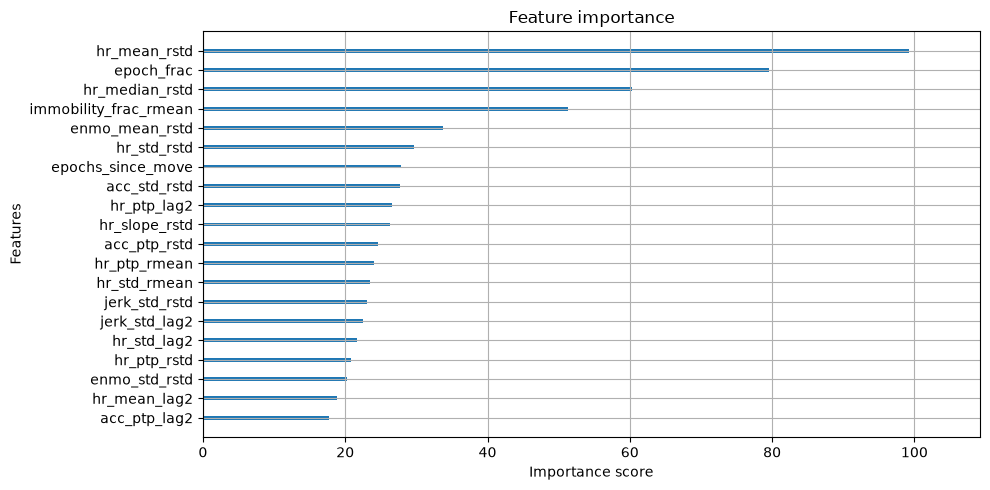

In [8]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

_, ax = plt.subplots(1,1,figsize=(10,5))
plot_importance(model, ax=ax, importance_type='gain', max_num_features=20, show_values=False)
plt.tight_layout()
plt.show()

## Feature importance con SHAP

El `gain` de arriba tiene un problema con nuestras features: están muy **correlacionadas** (cada feature base genera `_lag/_lead/_delta/_rmean/_rstd`, y hay pares casi redundantes como `hr_mean`/`hr_median`). XGBoost reparte el `gain` de forma arbitraria entre features correlacionadas, así que ese ranking puede subestimar señales reales.

**SHAP** (*SHapley Additive exPlanations*) atribuye a cada feature su contribución marginal promedio a la predicción, con base teórica en los valores de Shapley de teoría de juegos. Ventajas para nuestro caso:

- Reparte mejor el crédito entre features correlacionadas.
- Da la importancia **por clase** (Wake / N1 / N2 / N3 / REM), no solo global: permite verificar la hipótesis fisiológica (HRV pesa en REM/N3, movimiento en Wake).

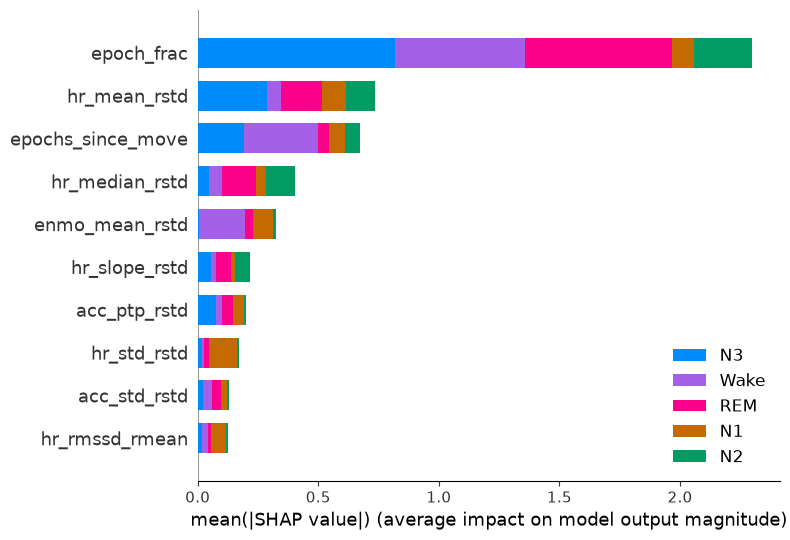

In [9]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
4
class_names = ['Wake', 'N1', 'N2', 'N3', 'REM']

shap.summary_plot(shap_values, X_test, plot_type='bar', class_names=class_names, max_display=10, show=True)

En ambos enfoques (gain y SHAP) se destaca el índice de época (`epoch_frac`). Esto admite dos lecturas complementarias:

1. La arquitectura del sueño tiene una estructura temporal fuerte y aprendible a nivel poblacional: la etapa esperable depende mucho de la fracción de la noche (N3 domina el primer tercio, REM el último). El modelo explota este prior. Como contrapartida, apoyarse tanto en la posición (y no en la señal del reloj) implica un riesgo de peor generalización a noches atípicas, donde la arquitectura se desvía del promedio.
2. El posicionamiento temporal es clave, lo que sugiere que un modelo capaz de modelar dependencias temporales explícitas (LSTM/BiLSTM) sobre la secuencia de épocas debería mejorar las predicciones respecto del baseline por época.

Además, las features de contexto local (`_rmean`, `_rstd`, calculadas sobre ventanas de épocas vecinas) también figuran alto, lo que refuerza la misma idea: la información de las épocas adyacentes es relevante, y un modelo secuencial puede capturarla de forma nativa en lugar de tener que inyectarla a mano como features.

# **Red Neuronal Densa (MLP)**

Segundo modelo del baseline sobre las mismas features tabulares por época: una red densa (MLP) entrenada en PyTorch, comparada contra el XGBoost.

In [23]:

import sys
sys.path.append("..")

import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, f1_score, cohen_kappa_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, precision_recall_curve, average_precision_score,
)
from sklearn.preprocessing import label_binarize

from src.mlp import MLP, get_dataloaders, train_model, predict, permutation_importance

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Red Neuronal Densa (MLP) sobre features tabulares

Entrenamos y evaluamos un **MLP (perceptrón multicapa)** — una red neuronal *feedforward* — sobre las **features tabulares por época** (`epoch_features.csv`): un vector de descriptores ya calculados para cada ventana de 30 s (features de HR, HRV y acelerometría, más contexto de épocas vecinas). El modelo recibe ese vector y predice la etapa de sueño (Wake, N1, N2, N3, REM).

## Preprocesamiento y partición

Un MLP requiere dos pasos que preparan los datos tabulares:

1. **Imputación de NaN.** Las features de contexto (`_lag`, `_lead`, `_delta`, `_rmean`, `_rstd`) quedan como `NaN` en los bordes de cada noche. Una red densa propaga los `NaN`, así que se imputan con la **mediana** de cada feature, calculada **sólo sobre train**.
2. **Estandarización.** Las features viven en escalas muy distintas (bpm, g, fracciones, conteos); un `StandardScaler` (media 0, desvío 1) evita que las de mayor magnitud dominen el gradiente. También **fiteado sólo en train**.

**Partición.** Se divide **por paciente** (`GroupShuffleSplit` sobre `subject`): dev/test 80/20 y dentro de dev train/val 80/20. Particionar por paciente (y no por época) evita fuga de información, porque las épocas de una misma noche están muy correlacionadas.

**Desbalance.** N2 domina y N1 es escasa. El parámetro `weight_mode` controla los pesos de clase de la loss. En esta corrida usamos **`weight_mode='none'`** (sin pesos): **maximiza accuracy y kappa** a costa del recall de las clases chicas (N1 casi no se detecta → baja el F1-macro). `'sqrt'` sería el punto intermedio y `'balanced'` el que prioriza el F1-macro.

In [24]:
train_loader, val_loader, test_loader, class_weights, dreem_test, input_dim = get_dataloaders(
    batch_size=512, random_state=42, weight_mode="none"
)

CSV: ../data_extraction/epoch_features.csv
Features: 122 | train: 121829  val: 35897  test: 46212
Class weights (none): {0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0, 4: 1.0}


## Arquitectura del MLP

Bloques densos `Linear -> BatchNorm -> ReLU -> Dropout` (256 -> 128 -> 64) y una capa final a las 5 etapas:

- **Entrada**: vector de features por época (`input_dim`).
- `BatchNorm1d` estabiliza el entrenamiento; `Dropout(0.3)` regulariza.
- **Salida**: 5 logits; la `CrossEntropyLoss` aplica el softmax internamente.

In [25]:
model = MLP(input_dim=input_dim, num_classes=5, hidden_dims=(256, 128, 64), dropout=0.3)
print(model)

MLP(
  (net): Sequential(
    (0): Linear(in_features=122, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=64, out_features=5, bias=True)
  )
)


## Entrenamiento

Optimizador **Adam**, loss **ponderada por clase**, **`ReduceLROnPlateau`** (baja el lr si la val loss se estanca) y **early stopping** (restaura el mejor modelo según val loss).

## Elección de hiperparámetros

La arquitectura y el entrenamiento se eligieron buscando un modelo **simple y bien regularizado**. En datos tabulares una red densa suele rendir a la par de los árboles de gradiente, y agregar capacidad tiende a **sobreajustar** antes que a mejorar la generalización, así que se priorizó la regularización sobre el tamaño.

| Hiperparámetro | Valor | Justificación |
|---|---|---|
| Capas ocultas | 256 → 128 → 64 | Embudo que comprime las ~122 features a una representación cada vez más compacta. Profundidad moderada: alcanza para capturar interacciones no lineales sin la tendencia a sobreajustar de redes más profundas sobre datos tabulares. |
| Activación | ReLU | Estándar, barata y sin saturación en redes feedforward. |
| `BatchNorm1d` | en cada capa oculta | Normaliza las activaciones intermedias: estabiliza y acelera el entrenamiento, clave con features de escalas mixtas (bpm, g, conteos). |
| Dropout | 0.5 | Las features de contexto (`_lag`/`_lead`/`_rmean`…) están muy correlacionadas y la red sobreajusta fácil; el dropout la fuerza a no depender de neuronas puntuales. |
| Optimizador | Adam | Robusto y poco sensible al ajuste inicial del learning rate. |
| Learning rate | 5e-4 | Más chico que el default de Adam para suavizar la oscilación del val accuracy cerca del mínimo. |
| `weight_decay` | 1e-4 | L2 leve que penaliza pesos grandes, complementa al dropout. |
| `batch_size` | 512 | Con ~123k épocas de train; un batch más grande da un gradiente aún más estable (menos oscilación en validación). |
| Loss | CrossEntropy **(`none`)** | Dataset muy desbalanceado (N2 ≫ N1). En esta corrida sin pesos de clase, para maximizar accuracy y kappa (a costa del F1-macro / N1). El dial `weight_mode` admite `'balanced'`, `'sqrt'` o `'none'`. |
| Scheduler | `ReduceLROnPlateau` (patience 5, factor 0.5) | Cuando la val loss se estanca, baja el lr a la mitad para afinar con pasos más chicos. |
| Early stopping | patience 10 | Corta si la val loss no mejora en 12 epochs y **restaura el mejor modelo**. |
| `epochs` | 100 (techo) | Sólo un límite superior; el early stopping corta mucho antes. |

**Compromiso desbalance ↔ métricas.** Ponderar la loss mejora el *recall* de las clases chicas (sube el **F1-macro**) a costa de *accuracy* y *kappa*. El parámetro `weight_mode` controla ese dial: `'balanced'` (máximo F1-macro), `'sqrt'` (equilibrio) o `'none'` (máxima accuracy/kappa, usado acá).

In [26]:
model, history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    class_weights=class_weights,
    epochs=100,
    lr=5e-4,
    patience=10,
)

Epoch   1 | Train Loss: 1.2684 | Val Loss: 1.2083 | Val Acc: 0.497
Epoch   2 | Train Loss: 1.1695 | Val Loss: 1.1889 | Val Acc: 0.509
Epoch   3 | Train Loss: 1.1502 | Val Loss: 1.1761 | Val Acc: 0.515
Epoch   4 | Train Loss: 1.1370 | Val Loss: 1.1728 | Val Acc: 0.517
Epoch   5 | Train Loss: 1.1294 | Val Loss: 1.1745 | Val Acc: 0.512
Epoch   6 | Train Loss: 1.1239 | Val Loss: 1.1706 | Val Acc: 0.516
Epoch   7 | Train Loss: 1.1186 | Val Loss: 1.1740 | Val Acc: 0.518
Epoch   8 | Train Loss: 1.1152 | Val Loss: 1.1687 | Val Acc: 0.520
Epoch   9 | Train Loss: 1.1107 | Val Loss: 1.1719 | Val Acc: 0.517
Epoch  10 | Train Loss: 1.1061 | Val Loss: 1.1657 | Val Acc: 0.519
Epoch  11 | Train Loss: 1.1026 | Val Loss: 1.1730 | Val Acc: 0.519
Epoch  12 | Train Loss: 1.1007 | Val Loss: 1.1660 | Val Acc: 0.520
Epoch  13 | Train Loss: 1.0972 | Val Loss: 1.1670 | Val Acc: 0.517
Epoch  14 | Train Loss: 1.0950 | Val Loss: 1.1699 | Val Acc: 0.518
Epoch  15 | Train Loss: 1.0916 | Val Loss: 1.1638 | Val Acc: 0

### Curva de loss (train vs. validación)

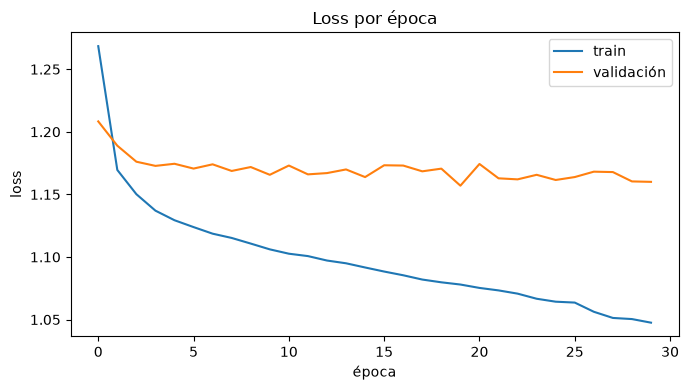

In [27]:
plt.figure(figsize=(7, 4))
plt.plot(history['train_loss'], label='train')
plt.plot(history['val_loss'], label='validación')
plt.xlabel('época')
plt.ylabel('loss')
plt.title('Loss por época')
plt.legend()
plt.tight_layout()
plt.show()

## Métricas en test

Sobre el conjunto de **test** reportamos **Accuracy**, **F1-score (macro)** y **Cohen's Kappa** de las predicciones contra la etiqueta del experto (el target). El F1-macro (promedio simple por clase) y el kappa (descuenta el acierto por azar sobre la mayoritaria) son las métricas honestas bajo desbalance.

Como **comparativa**, agregamos a **Dreem**: su etiquetado automático basado en EEG, evaluado también contra el Expert. Dreem es un dispositivo dedicado (mucho más informativo que HR + acelerometría), así que sus métricas funcionan como una **cota de referencia alta**. Para que sea justo, ambos se evalúan sobre las mismas épocas: aquellas donde Dreem produjo etiqueta (descartando sus *Unknown*).

In [28]:
y_true, y_pred = predict(model, test_loader)

def resumen(nombre, y_t, y_p):
    acc = accuracy_score(y_t, y_p)
    f1 = f1_score(y_t, y_p, average='macro')
    kappa = cohen_kappa_score(y_t, y_p)
    print(f"{nombre:20} Accuracy {acc:.3f} | F1-macro {f1:.3f} | Kappa {kappa:.3f}")

resumen("MLP (test completo)", y_true, y_pred)

mask = dreem_test != 5
print(f"\nComparativa vs Expert (épocas con Dreem válido: {mask.sum()} de {len(mask)}):")
resumen("  MLP", y_true[mask], y_pred[mask])
resumen("  Dreem", y_true[mask], dreem_test[mask])

MLP (test completo)  Accuracy 0.532 | F1-macro 0.453 | Kappa 0.357

Comparativa vs Expert (épocas con Dreem válido: 46166 de 46212):
  MLP                Accuracy 0.532 | F1-macro 0.453 | Kappa 0.358
  Dreem              Accuracy 0.828 | F1-macro 0.729 | Kappa 0.768


## Desglose por clase

Los agregados (accuracy, F1-macro, kappa) esconden *dónde* falla el modelo. El `classification_report` muestra **precision, recall y F1 por etapa**. El F1-macro (0.48) por debajo de la accuracy (0.53) ya anticipa que hay clases flojas — típicamente **N1**, la minoritaria y más ambigua.

In [29]:
print(classification_report(y_true, y_pred, target_names=['Wake', 'N1', 'N2', 'N3', 'REM']))

              precision    recall  f1-score   support

        Wake       0.70      0.64      0.67      5496
          N1       0.00      0.00      0.00      3251
          N2       0.53      0.57      0.55     16848
          N3       0.57      0.48      0.52      8964
         REM       0.46      0.62      0.53     11653

    accuracy                           0.53     46212
   macro avg       0.45      0.46      0.45     46212
weighted avg       0.50      0.53      0.51     46212



## Matriz de confusión (5 clases)

Muestra con qué se confunde cada etapa: fuera de la diagonal están los errores (N1↔N2, N2↔N3, REM↔Wake…).

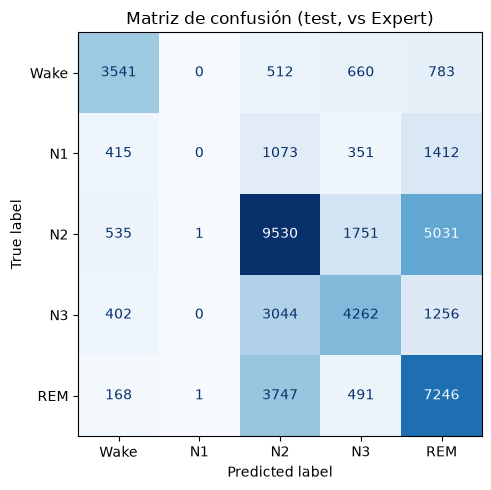

In [30]:
cm = confusion_matrix(y_true, y_pred, labels=range(5))
disp = ConfusionMatrixDisplay(cm, display_labels=['Wake', 'N1', 'N2', 'N3', 'REM'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Matriz de confusión (test, vs Expert)')
plt.tight_layout(); plt.show()

## Curvas ROC y Precision-Recall

Al ser un problema multiclase, se grafican en esquema **one-vs-rest**: una curva por etapa. La **ROC** (TPR vs. FPR, con su AUC) resume la capacidad de ranking del modelo por clase, mientras que la **Precision-Recall** (con su *Average Precision*) es más informativa bajo el fuerte desbalance porque no premia el acierto trivial de la clase negativa mayoritaria. Se espera ver curvas pobres en **N1** (la clase marginal, casi no detectada) y mejores en Wake/N3/REM.

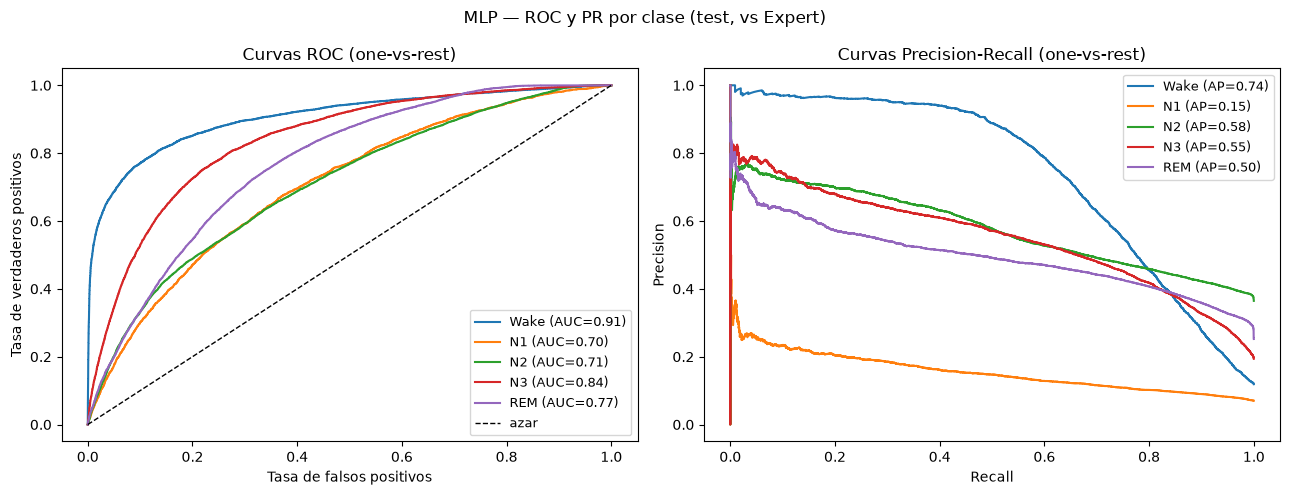

In [31]:
@torch.no_grad()
def predict_proba(model, loader, device=None):
    device = device or torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device).eval()
    probs = [torch.softmax(model(X.to(device)), dim=1).cpu().numpy() for X, _ in loader]
    return np.concatenate(probs)

y_score = predict_proba(model, test_loader)
names = ['Wake', 'N1', 'N2', 'N3', 'REM']
y_bin = label_binarize(y_true, classes=list(range(5)))

fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(13, 5))

for i, name in enumerate(names):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_score[:, i])
    ax_roc.plot(fpr, tpr, label=f'{name} (AUC={auc(fpr, tpr):.2f})')
ax_roc.plot([0, 1], [0, 1], 'k--', lw=1, label='azar')
ax_roc.set_xlabel('Tasa de falsos positivos')
ax_roc.set_ylabel('Tasa de verdaderos positivos')
ax_roc.set_title('Curvas ROC (one-vs-rest)')
ax_roc.legend(loc='lower right', fontsize=9)

for i, name in enumerate(names):
    prec, rec, _ = precision_recall_curve(y_bin[:, i], y_score[:, i])
    ap = average_precision_score(y_bin[:, i], y_score[:, i])
    ax_pr.plot(rec, prec, label=f'{name} (AP={ap:.2f})')
ax_pr.set_xlabel('Recall')
ax_pr.set_ylabel('Precision')
ax_pr.set_title('Curvas Precision-Recall (one-vs-rest)')
ax_pr.legend(loc='upper right', fontsize=9)

fig.suptitle('MLP — ROC y PR por clase (test, vs Expert)')
plt.tight_layout()
plt.show()

## Vista de 4 clases (Wake / Light / Deep / REM)

Colapsamos las etapas NREM (**N1+N2 → Light**, **N3 → Deep**) para comparar de forma justa con el paper del dataset (que reporta 4 clases) y con los otros notebooks (baseline y LSTM). La frontera N1/N2 es la más ambigua incluso entre expertos, así que colapsarla mide qué tan bien separamos los macro-estados fisiológicos. **No se reentrena**: se aplica el mismo mapeo a predicciones y target.

Expert (4 clases)  ->  Accuracy: 0.555   F1-macro: 0.569   Kappa: 0.365
Dreem  (4 clases)  ->  Accuracy: 0.551   F1-macro: 0.561   Kappa: 0.360

              precision    recall  f1-score   support

        Wake       0.70      0.64      0.67      5496
       Light       0.59      0.53      0.56     20099
        Deep       0.57      0.48      0.52      8964
         REM       0.46      0.62      0.53     11653

    accuracy                           0.56     46212
   macro avg       0.58      0.57      0.57     46212
weighted avg       0.57      0.56      0.56     46212



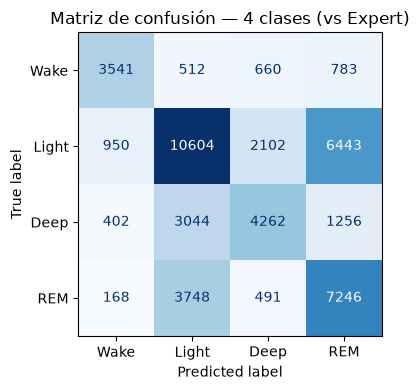

In [32]:
map4 = {0: 0, 1: 1, 2: 1, 3: 2, 4: 3}
names4 = ['Wake', 'Light', 'Deep', 'REM']
remap = np.vectorize(map4.get)

y_true4, y_pred4 = remap(y_true), remap(y_pred)

print(f"Expert (4 clases)  ->  Accuracy: {accuracy_score(y_true4, y_pred4):.3f}   "
      f"F1-macro: {f1_score(y_true4, y_pred4, average='macro'):.3f}   "
      f"Kappa: {cohen_kappa_score(y_true4, y_pred4):.3f}")

mask = dreem_test != 5
d4, p4 = remap(dreem_test[mask]), remap(y_pred[mask])
print(f"Dreem  (4 clases)  ->  Accuracy: {accuracy_score(d4, p4):.3f}   "
      f"F1-macro: {f1_score(d4, p4, average='macro'):.3f}   "
      f"Kappa: {cohen_kappa_score(d4, p4):.3f}")
print()
print(classification_report(y_true4, y_pred4, target_names=names4))

cm4 = confusion_matrix(y_true4, y_pred4, labels=range(4))
disp4 = ConfusionMatrixDisplay(cm4, display_labels=names4)
fig, ax = plt.subplots(figsize=(5, 4))
disp4.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Matriz de confusión — 4 clases (vs Expert)')
plt.tight_layout(); plt.show()

## Importancia de features (permutation importance)

El MLP no es interpretable directo como un árbol (no hay `feature_importance` ni SHAP fácil). Medimos la importancia por **permutación**: se baraja cada feature en el test y se mide cuánto **cae el Kappa**. Una caída grande = feature importante para el modelo. Es el análogo neuronal del análisis de importancia del XGBoost.

(Puede tardar un poco: reevalúa el test una vez por feature.)

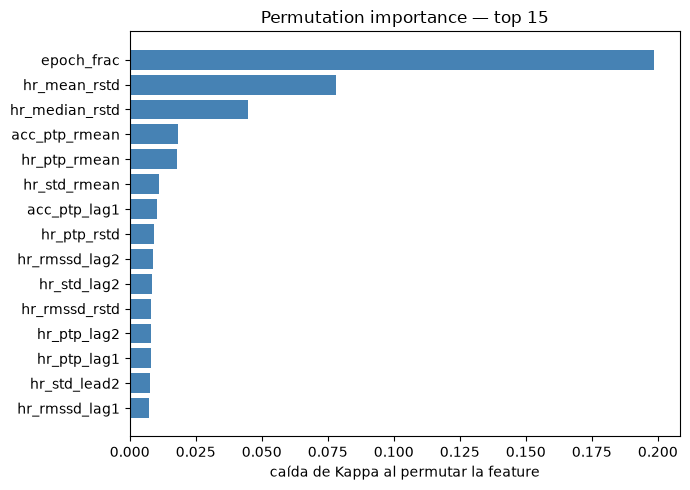

In [33]:
imp = permutation_importance(model, n_repeats=3, top=15)

feats = [f for f, _ in imp][::-1]
vals = [v for _, v in imp][::-1]

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(feats, vals, color='steelblue')
ax.set_xlabel('caída de Kappa al permutar la feature')
ax.set_title('Permutation importance — top 15')
plt.tight_layout(); plt.show()